# Example Solver Usage: Unlabeled Coordinated Motion Planning in Graphs

In [21]:
import random
from typing import Any

import networkx as nx

from unlabeled_cmp_solver import Instance, optimize_makespan, visualize_schedule

Node = Any

## Helper functions for creating instances

In [22]:
def create_grid_with_layout(n: int, m: int) -> nx.Graph:
    """Creates n x m grid with respective vertex positions."""
    G = nx.grid_2d_graph(6, 6)
    for node in G.nodes:
        G.nodes[node]["pos"] = (node[1], -node[0])
    return G

def select_random_start_target(G: nx.Graph, k: int, seed: int=None) -> tuple[list[Node], list[Node]]:
    """Selects k random start and target positions each from a given graph."""
    if seed is not None:
        random.seed(seed)
    all_nodes = list(G.nodes)
    start_positions = random.sample(all_nodes, k)
    target_positions = random.sample(all_nodes, k)
    return start_positions, target_positions

## Create Instance

In [23]:
i, j = 7, 7
G = create_grid_with_layout(i,j)
start_positions, target_positions = select_random_start_target(G, 6)
instance = Instance(G, start_positions, target_positions)

print(f"Grid size: {i} x {j}")
print(f"Robots: {len(start_positions)}")
print(f"Diameter: {instance.diameter}")

Grid size: 7 x 7
Robots: 6
Diameter: 3


## Solve Instance

Instance solved!
Optimal makespan: 3
{'probe(m=71)': {'network_nodes': 13670, 'network_arcs': 26424, 'flow_value': 6, 'feasible': True, 'network_construction_time': 0.0050427913665771484, 'max_flow_time': 0.0006589889526367188}, 'probe(m=37)': {'network_nodes': 7142, 'network_arcs': 13776, 'flow_value': 6, 'feasible': True, 'network_construction_time': 0.0017189979553222656, 'max_flow_time': 0.0002918243408203125}, 'probe(m=20)': {'network_nodes': 3878, 'network_arcs': 7452, 'flow_value': 6, 'feasible': True, 'network_construction_time': 0.0008661746978759766, 'max_flow_time': 0.00015211105346679688}, 'probe(m=11)': {'network_nodes': 2150, 'network_arcs': 4104, 'flow_value': 6, 'feasible': True, 'network_construction_time': 0.0005159378051757812, 'max_flow_time': 7.295608520507812e-05}, 'probe(m=7)': {'network_nodes': 1382, 'network_arcs': 2616, 'flow_value': 6, 'feasible': True, 'network_construction_time': 0.0003249645233154297, 'max_flow_time': 4.76837158203125e-05}, 'probe(m=5)': {

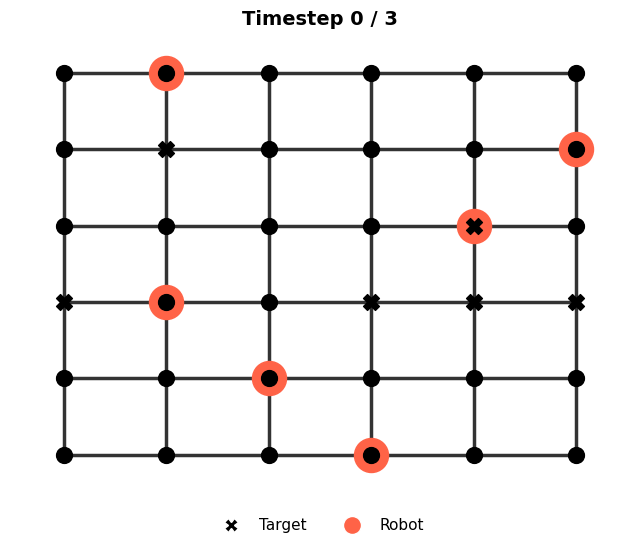

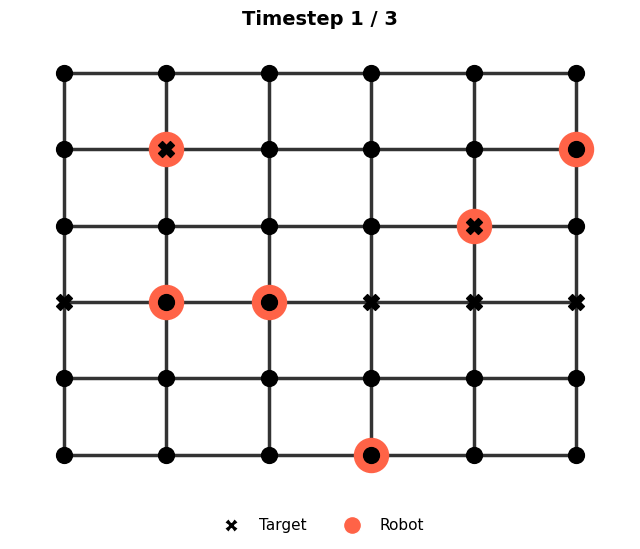

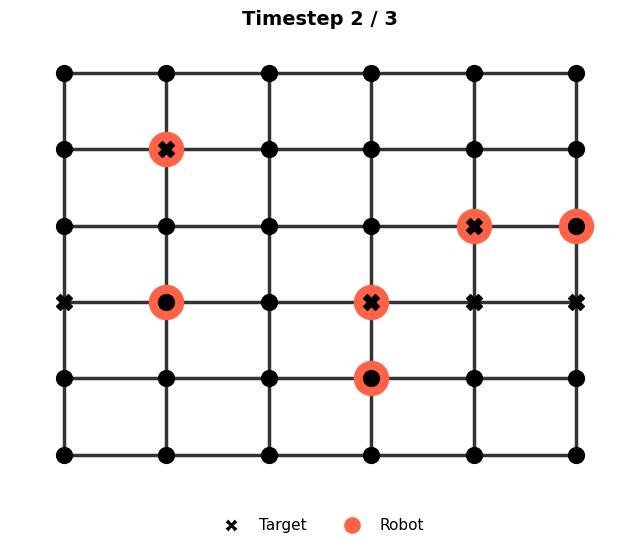

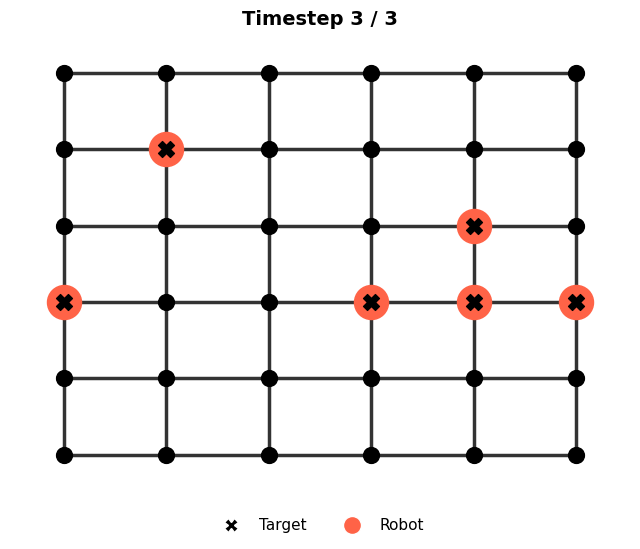

In [24]:
schedule, stats = optimize_makespan(instance)
assert schedule.fits_instance(instance), "computed schedule is not feasible"

print("Instance solved!")
print(f"Optimal makespan: {schedule.makespan}")
print(stats)
visualize_schedule(instance, schedule)